cell 1 Imports & Raw Data Load

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, ttest_rel, wilcoxon, linregress

FILE_24 = 'MasterChaparralTransect_final24_lat_long.xlsx'
FILE_25 = 'MasterChaparralTransect_final25_lat_long.xlsx'

woody_24_raw = pd.read_excel(FILE_24, sheet_name='Woody Species Cover')
woody_25_raw = pd.read_excel(FILE_25, sheet_name='Woody Species Cover')
herb_24_raw  = pd.read_excel(FILE_24, sheet_name='Herbaceous Understory Cover')
herb_25_raw  = pd.read_excel(FILE_25, sheet_name='Herbaceous Understory Cover')

print(f"2024 Woody : {woody_24_raw.shape}")
print(f"2025 Woody : {woody_25_raw.shape}")
print(f"2024 Herb  : {herb_24_raw.shape}")
print(f"2025 Herb  : {herb_25_raw.shape}")

2024 Woody : (423, 7)
2025 Woody : (108, 6)
2024 Herb  : (802, 12)
2025 Herb  : (1127, 9)


cell 2 Column Cleaning & Standardisation

1.Lowercase + underscores + strip special chars
2.Rename transect column → 'transect_id'

3.Strip whitespace; replace 'nan' string → actual NaN

4.str.upper() on transect_id also fixes
the confirmed raw typo

5.'MAs09' (lowercase s) present in both 2025 fuel sheets.

In [ ]:


def clean_col_names(df):
    df = df.copy()
    df.columns = (df.columns.astype(str).str.strip().str.lower()
                  .str.replace(r'\s+', '_', regex=True)
                  .str.replace(r'[^a-z0-9_]', '', regex=True))
    return df

def rename_transect(df):
    candidates = [c for c in df.columns if 'transect' in c]
    if candidates:
        df = df.rename(columns={candidates[0]: 'transect_id'})
    return df

def strip_strings(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().replace('nan', np.nan)
    df['transect_id'] = df['transect_id'].str.upper()  # fixes 'MAs09' typo
    return df

woody_24 = strip_strings(rename_transect(clean_col_names(woody_24_raw)))
woody_25 = strip_strings(rename_transect(clean_col_names(woody_25_raw)))
herb_24  = strip_strings(rename_transect(clean_col_names(herb_24_raw)))
herb_25  = strip_strings(rename_transect(clean_col_names(herb_25_raw)))

if '1species' in herb_25.columns:
    herb_25 = herb_25.rename(columns={'1species': 'species'})

print(" Cleaning done. Known raw typo 'MAs09' → 'MAS09' corrected via .str.upper()")
print(f"   woody_24 cols : {woody_24.columns.tolist()}")
print(f"   herb_25  cols : {herb_25.columns.tolist()}")

 Cleaning done. Known raw typo 'MAs09' → 'MAS09' corrected via .str.upper()
   woody_24 cols : ['collection_date', 'transect_id', 'woody_species', 'start_m', 'stop_m', 'height_3m_interval', 'comments']
   herb_25  cols : ['transect_id', 'quadrat_interval', 'species', 'native_status', 'species_notes', 'species_lifeform_class', 'percent_cover', 'comments', 'unnamed_8']


In [ ]:
print(herb_25['unnamed_8'].isna().sum(), len(herb_25))
print(herb_25['unnamed_8'].dropna().head(10))

1126 1127
318    raw data only stated Ceanothus
Name: unnamed_8, dtype: object


In [ ]:
# Fix safer .str.upper() — only runs if column exists
def strip_strings(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip().replace('nan', np.nan)
    if 'transect_id' in df.columns:
        df['transect_id'] = df['transect_id'].str.upper()
    return df

# Check unnamed_8 in herb_25
print(herb_25['unnamed_8'].isna().sum(), len(herb_25))
print(herb_25['unnamed_8'].dropna().head(10))

# Merge the one note into comments, then drop the garbage column
if 'unnamed_8' in herb_25.columns:
    herb_25['comments'] = herb_25['comments'].fillna('')
    herb_25['unnamed_8'] = herb_25['unnamed_8'].fillna('')
    herb_25['comments'] = herb_25.apply(
        lambda row: f"{row['comments']} | {row['unnamed_8']}".strip(' |')
        if row['unnamed_8'] else row['comments'],
        axis=1
    )
    herb_25 = herb_25.drop(columns=['unnamed_8'])
    print(f" unnamed_8 merged into comments and dropped.")
    print(f"   herb_25 final cols: {herb_25.columns.tolist()}")

1126 1127
318    raw data only stated Ceanothus
Name: unnamed_8, dtype: object
 unnamed_8 merged into comments and dropped.
   herb_25 final cols: ['transect_id', 'quadrat_interval', 'species', 'native_status', 'species_notes', 'species_lifeform_class', 'percent_cover', 'comments']


cell 3 Woody Cover

 METHOD: woody_cover_% = (sum of intercept segment lengths / 30m) × 100

 Calculates woody percent cover per transect for 2024 and 2025. Each intercepted segment length is summed per transect and divided by the 30m transect length. Flags reversed entries (stop < start), zero-length segments, and tiny segments under 1cm as likely field recording errors. Ends with a transect coverage check to identify any transects missing in one year.


In [ ]:


TRANSECT_LENGTH_M = 30.0


def calc_woody_cover_pct(df, label):
    df = df.copy()
    start_col = [c for c in df.columns if 'start' in c][0]
    stop_col  = [c for c in df.columns if 'stop'  in c][0]

    df[start_col] = pd.to_numeric(df[start_col], errors='coerce')
    df[stop_col]  = pd.to_numeric(df[stop_col],  errors='coerce')

    n_before = len(df)
    df = df.dropna(subset=[start_col, stop_col])

    mask_reversed = df[stop_col] < df[start_col]
    if mask_reversed.sum() > 0:
        print(f"[{label}] {mask_reversed.sum()} reversed row(s) corrected (abs):")
        print(df[mask_reversed][['transect_id', start_col, stop_col]].to_string(index=False))

    df['segment_m'] = (df[stop_col] - df[start_col]).abs()

    zero_segs = df[df['segment_m'] == 0]
    if len(zero_segs):
        print(f"[{label}] Zero-length segment(s) — 0 contribution to cover:")
        print(zero_segs[['transect_id', start_col, stop_col]].to_string(index=False))

    tiny = df[(df['segment_m'] > 0) & (df['segment_m'] <= 0.01)]
    if len(tiny):
        print(f"[{label}] Tiny segment(s) (<=1 cm) — likely decimal entry errors:")
        print(tiny[['transect_id', start_col, stop_col, 'segment_m']].to_string(index=False))

    print(f"[{label}] Zero-length segments : {len(zero_segs)}")
    print(f"[{label}] Tiny segments (<=1cm): {len(tiny)}")
    print(f"[{label}] NaN rows dropped     : {n_before - len(df)}")

    total = (df.groupby('transect_id')['segment_m']
               .sum().reset_index()
               .rename(columns={'segment_m': 'total_m'}))
    total['woody_pct'] = (total['total_m'] / TRANSECT_LENGTH_M * 100).round(4)

    print(f"[{label}] Transects computed   : {len(total)}")
    return total[['transect_id', 'woody_pct']]


woody_2024 = calc_woody_cover_pct(woody_24, '2024')
woody_2025 = calc_woody_cover_pct(woody_25, '2025')

missing_in_2025 = sorted(set(woody_2024['transect_id']) - set(woody_2025['transect_id']))
missing_in_2024 = sorted(set(woody_2025['transect_id']) - set(woody_2024['transect_id']))
print("\nTransect coverage check")
print(f"Missing in 2025: {missing_in_2025}")
print(f"Missing in 2024: {missing_in_2024}")

print("\n woody_2024")
print(woody_2024.to_string(index=False))
print("\n woody_2025")
print(woody_2025.to_string(index=False))

[2024] 2 reversed row(s) corrected (abs):
transect_id  start_m  stop_m
      MAS13    15.42   14.59
      MAS27    24.21   24.07
[2024] Zero-length segment(s) — 0 contribution to cover:
transect_id  start_m  stop_m
      MAS07    29.51   29.51
[2024] Tiny segment(s) (<=1 cm) — likely decimal entry errors:
transect_id  start_m  stop_m  segment_m
      MAS03    13.96  13.970      0.010
      MAS03    15.05  15.060      0.010
      MAS05    15.33  15.334      0.004
      MAS05    15.99  15.992      0.002
      MAS07     8.80   8.810      0.010
      MAS20    21.78  21.790      0.010
      MAS23     0.83   0.833      0.003
      MAS23    23.44  23.450      0.010
      MAS27    29.48  29.490      0.010
      MAS28     4.78   4.790      0.010
      MAS28    18.53  18.540      0.010
[2024] Zero-length segments : 1
[2024] Tiny segments (<=1cm): 11
[2024] NaN rows dropped     : 0
[2024] Transects computed   : 18
[2025] Zero-length segments : 0
[2025] Tiny segments (<=1cm): 0
[2025] NaN rows dro

cell 4

Calculates mean herbaceous percent cover per transect for 2024 and 2025. Non-standard quadrat positions are remapped to the nearest standard interval (3, 9, 15, 21, 27m) if within 1.5m, otherwise dropped. Non-vegetation rows (bare ground, rock, litter, ash, etc.) are filtered out by lifeform class code and species name. Cover is summed within each quadrat first, then averaged across quadrats per transect.

In [ ]:
import numpy as np

STANDARD_QUADRATS_ARR = np.array([3, 9, 15, 21, 27])
STANDARD_QUADRATS     = set(STANDARD_QUADRATS_ARR)

NON_VEG_CLASS    = {'BG', 'LI', 'RO', 'WD', 'AS', 'CL', 'CWD', 'WA'}
NON_VEG_KEYWORDS = ['bare ground', 'rock', 'litter', 'duff', 'ash',
                    'water', 'woody debris', 'coarse woody debris', 'charred litter']


def map_to_standard(q):
    return int(STANDARD_QUADRATS_ARR[np.argmin(np.abs(STANDARD_QUADRATS_ARR - q))])


def calc_herb_cover_pct(df, label):
    df = df.copy()
    df['percent_cover']    = pd.to_numeric(df['percent_cover'],    errors='coerce')
    df['quadrat_interval'] = pd.to_numeric(df['quadrat_interval'], errors='coerce')

    n_raw = len(df)
    df = df.dropna(subset=['transect_id', 'percent_cover', 'quadrat_interval'])
    print(f"[{label}] NaN rows dropped: {n_raw - len(df)}")

    # Step 1: separate standard vs non-standard rows
    std_rows    = df[df['quadrat_interval'].isin(STANDARD_QUADRATS)].copy()
    nonstd_rows = df[~df['quadrat_interval'].isin(STANDARD_QUADRATS)].copy()

    # Step 2-4b: only run mapping logic if non-standard rows exist
    if len(nonstd_rows) == 0:
        near_rows  = pd.DataFrame(columns=df.columns)
        far_rows   = pd.DataFrame(columns=df.columns)
        collisions = pd.DataFrame(columns=df.columns)
        print(f"[{label}] All intervals are standard — no remapping needed")
    else:
        nonstd_rows['nearest_std'] = nonstd_rows['quadrat_interval'].apply(map_to_standard)
        nonstd_rows['dist_to_std'] = nonstd_rows['quadrat_interval'].apply(
            lambda q: np.min(np.abs(STANDARD_QUADRATS_ARR - q))
        )

        far_rows  = nonstd_rows[nonstd_rows['dist_to_std'] > 1.5]
        near_rows = nonstd_rows[nonstd_rows['dist_to_std'] <= 1.5].copy()

        if len(far_rows):
            print(f"[{label}] {len(far_rows)} row(s) >1.5m from any standard — DROPPED (ambiguous):")
            print(far_rows[['transect_id','quadrat_interval','species','percent_cover']].to_string(index=False))

        # Step 3: map near rows to nearest standard position
        near_rows['quadrat_interval'] = near_rows['nearest_std']

        # Step 4: collision check — standard position always wins
        std_keys = set(zip(std_rows['transect_id'], std_rows['quadrat_interval']))
        collision_mask = near_rows.apply(
            lambda r: (r['transect_id'], r['quadrat_interval']) in std_keys, axis=1
        )
        collisions = near_rows[collision_mask]
        near_rows  = near_rows[~collision_mask]

        if len(collisions):
            print(f"[{label}] {len(collisions)} mapped row(s) collide with existing standard — DROPPED:")
            print(collisions[['transect_id','quadrat_interval','species','percent_cover']].to_string(index=False))

        # Step 4b: if two non-standard rows from same transect map to same position,
        # keep only the closest one
        before_dedup = len(near_rows)
        near_rows = (near_rows
                     .sort_values('dist_to_std')
                     .drop_duplicates(subset=['transect_id','quadrat_interval'], keep='first'))
        deduped = before_dedup - len(near_rows)
        if deduped:
            print(f"[{label}] {deduped} near row(s) removed — two mapped to same position, kept closest")

        near_rows = near_rows.drop(columns=['nearest_std','dist_to_std'])

        print(f"[{label}] Rows remapped and kept  : {len(near_rows)}")
        print(f"[{label}] Rows dropped (ambiguous): {len(far_rows)}")
        print(f"[{label}] Rows dropped (collision): {len(collisions)}")

    # Step 5: merge standard + valid remapped rows
    df = pd.concat([std_rows, near_rows], ignore_index=True)

    lf_col = [c for c in df.columns if 'lifeform' in c or 'class' in c][0]

    # Filter A: lifeform class code
    mask_class   = df[lf_col].str.upper().isin(NON_VEG_CLASS)
    # Filter B: species name keyword
    mask_keyword = df['species'].str.lower().fillna('').str.contains(
                       '|'.join(NON_VEG_KEYWORDS), regex=True)
    excluded = mask_class | mask_keyword

    excl_classes = df[excluded][lf_col].str.upper().value_counts()
    print(f"[{label}] Non-veg excluded   : {excluded.sum()} rows")
    print(f"[{label}] Exclusion breakdown: {excl_classes.to_dict()}")

    blank_class = df[~excluded & (df[lf_col].isna() | (df[lf_col].str.strip() == ''))]
    if len(blank_class):
        print(f"[{label}] {len(blank_class)} blank lifeform class row(s) included as veg (conservative):")
        print(blank_class[['transect_id','species','percent_cover']].to_string(index=False))

    veg_df = df[~excluded].copy()
    print(f"[{label}] Veg rows retained  : {len(veg_df)}")

    # Step 6: sum species within each quadrat
    quad = (veg_df
            .groupby(['transect_id','quadrat_interval'])['percent_cover']
            .sum().reset_index()
            .rename(columns={'percent_cover':'quad_total'}))

    over_100 = quad[quad['quad_total'] > 100]
    if len(over_100):
        print(f"[{label}] {len(over_100)} quadrat(s) with total > 100% — review:")
        print(over_100.to_string(index=False))
    else:
        print(f"[{label}] All quadrat totals <= 100%")

    # Step 7: mean of quadrat totals per transect
    result = (quad
              .groupby('transect_id')['quad_total']
              .mean().reset_index()
              .rename(columns={'quad_total':'herb_pct'}))
    result['herb_pct'] = result['herb_pct'].round(4)

    print(f"[{label}] Transects computed : {len(result)}")
    return result


herb_2024 = calc_herb_cover_pct(herb_24, '2024')
herb_2025 = calc_herb_cover_pct(herb_25, '2025')

missing_herb_2025 = sorted(set(herb_2024['transect_id']) - set(herb_2025['transect_id']))
missing_herb_2024 = sorted(set(herb_2025['transect_id']) - set(herb_2024['transect_id']))
print("\nHerb transect coverage check")
print(f"Missing in 2025: {missing_herb_2025}")
print(f"Missing in 2024: {missing_herb_2024}")

print("\n herb_2024")
print(herb_2024.to_string(index=False))
print("\n herb_2025")
print(herb_2025.to_string(index=False))

[2024] NaN rows dropped: 2
[2024] 39 row(s) >1.5m from any standard — DROPPED (ambiguous):
transect_id  quadrat_interval      species  percent_cover
      MAS02               6.0         AVFA            0.3
      MAS02               6.0  Bare ground            3.9
      MAS02               6.0        BRDI3            0.6
      MAS02               6.0        BRHO2            0.7
      MAS02               6.0        BRRU2            0.9
      MAS02               6.0       CAAT25            0.2
      MAS02               6.0        CEME2            0.2
      MAS02               6.0        CLPUQ            0.7
      MAS02               6.0         ELGL            5.6
      MAS02               6.0      ERBER14            0.9
      MAS02               6.0        GAPOT            0.5
      MAS02               6.0        HYGL2           57.1
      MAS02               6.0       LEFI14            0.6
      MAS02               6.0         LOMI            1.5
      MAS02               6.0         R

/tmp/ipykernel_496/1027293355.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([std_rows, near_rows], ignore_index=True)


cell 5

Calculates total fuel load (tons/acre) per transect for 2024 and 2025 using Brown's planar intercept method. Sums four components (duff, litter, woody debris, herbaceous) at two sample distances (7m and 23m), then averages across distances. Missing components are flagged but not assumed zero. Output is used in Phase 4 to test whether fire intensity predicts vegetation change.

In [ ]:


fuel_24_raw = pd.read_excel(FILE_24, sheet_name='Fuel Loading ALL')
fuel_25_raw = pd.read_excel(FILE_25, sheet_name='Fuel Loading ALL')

def clean_fuel(df, label):
    df = df.copy()
    df.columns = (df.columns.astype(str).str.strip().str.lower()
                  .str.replace(r'\s+', '_', regex=True)
                  .str.replace(r'[^a-z0-9_]', '', regex=True))

    t_col = [c for c in df.columns if 'transect' in c][0]
    df = df.rename(columns={t_col: 'transect_id'})
    df['transect_id'] = df['transect_id'].astype(str).str.strip().str.upper()

    duff  = [c for c in df.columns if 'duff'  in c][0]
    litt  = [c for c in df.columns if 'litter' in c][0]
    woody = [c for c in df.columns if '1' in c and '10' in c and '100' in c][0]
    herb  = [c for c in df.columns if 'herb'  in c][0]
    dist  = [c for c in df.columns if 'dist'  in c][0]

    for col in [duff, litt, woody, herb]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Log NaN components before filling
    nan_mask = df[[duff, litt, woody, herb]].isnull().any(axis=1)
    if nan_mask.sum() > 0:
        print(f"[{label}] Rows with ≥1 missing component — NOT assumed zero:")
        print(df[nan_mask][['transect_id', dist, duff, litt, woody, herb]].to_string(index=False))
        print(f"[{label}]   These rows use sum of available components only.")
    else:
        print(f"[{label}] No missing components")

    # FIX: min_count=1 — sum available components, NaN only if ALL are missing
    df['total_fuel'] = df[[duff, litt, woody, herb]].sum(axis=1, min_count=1)

    # Distance coverage check — expect both 7m and 23m per transect
    dist_coverage = df.groupby('transect_id')[dist].nunique()
    incomplete = dist_coverage[dist_coverage < 2]
    if len(incomplete):
        print(f"[{label}]  Transects with <2 sample distances:")
        print(incomplete.to_string())
    else:
        print(f"[{label}]  All transects have both sample distances")

    return df[['transect_id', dist, 'total_fuel']]

fuel_24c = clean_fuel(fuel_24_raw, '2024')
fuel_25c = clean_fuel(fuel_25_raw, '2025')

# Average across sample distances per transect
fuel_2024_t = (fuel_24c.groupby('transect_id')['total_fuel']
               .mean().reset_index()
               .rename(columns={'total_fuel': 'fuel_2024'}))
fuel_2024_t['fuel_2024'] = fuel_2024_t['fuel_2024'].round(4)

fuel_2025_t = (fuel_25c.groupby('transect_id')['total_fuel']
               .mean().reset_index()
               .rename(columns={'total_fuel': 'fuel_2025'}))
fuel_2025_t['fuel_2025'] = fuel_2025_t['fuel_2025'].round(4)

# Transect coverage check
missing_fuel_2025 = sorted(set(fuel_2024_t['transect_id']) - set(fuel_2025_t['transect_id']))
missing_fuel_2024 = sorted(set(fuel_2025_t['transect_id']) - set(fuel_2024_t['transect_id']))
print("\nFuel transect coverage check ")
print(f"Missing in 2025: {missing_fuel_2025}")
print(f"Missing in 2024: {missing_fuel_2024}")

print("\nfuel_2024 ")
print(fuel_2024_t.to_string(index=False))
print("\nfuel_2025")
print(fuel_2025_t.to_string(index=False))

[2024] No missing components
[2024]  All transects have both sample distances
[2025] Rows with ≥1 missing component — NOT assumed zero:
transect_id  distance  duff   litter  1_10_100_woody  herbaceous
      MAS18        23     0 0.000002             NaN      0.0116
[2025]   These rows use sum of available components only.
[2025]  All transects have both sample distances

Fuel transect coverage check 
Missing in 2025: []
Missing in 2024: []

fuel_2024 
transect_id  fuel_2024
      MAS01     10.440
      MAS02      2.965
      MAS03     12.825
      MAS04     13.180
      MAS05     11.160
      MAS07      7.935
      MAS09     13.200
      MAS10     14.640
      MAS13      8.510
      MAS18     14.970
      MAS19     14.820
      MAS20      4.230
      MAS22      4.355
      MAS23     18.700
      MAS25      1.055
      MAS27     16.520
      MAS28      3.520
      MAS29     12.565

fuel_2025
transect_id  fuel_2025
      MAS01     0.0126
      MAS02     0.9514
      MAS03     0.0091
    

cell 6  Build Final Analysis Dataset

Merges woody cover, herbaceous cover, and fuel load from both years into one paired dataset. Computes change scores (delta) for each variable as 2025 minus 2024. MAS19 is excluded — it has no 2025 woody records and cannot form a pre/post pair. Output is saved as analysis_dataset_final.csv and used in all downstream Phase 3 and Phase 4 analyses.

In [ ]:


final_df = (
    woody_2024.rename(columns={'woody_pct': 'woody_2024'})
    .merge(woody_2025.rename(columns={'woody_pct': 'woody_2025'}), on='transect_id', how='inner')
    .merge(herb_2024.rename(columns={'herb_pct':  'herb_2024'}),   on='transect_id', how='inner')
    .merge(herb_2025.rename(columns={'herb_pct':  'herb_2025'}),   on='transect_id', how='inner')
    .merge(fuel_2024_t,                                             on='transect_id', how='inner')
    .merge(fuel_2025_t,                                             on='transect_id', how='inner')
    .sort_values('transect_id').reset_index(drop=True)
)

final_df['delta_woody'] = (final_df['woody_2025'] - final_df['woody_2024']).round(4)
final_df['delta_herb']  = (final_df['herb_2025']  - final_df['herb_2024']).round(4)
final_df['delta_fuel']  = (final_df['fuel_2025']  - final_df['fuel_2024']).round(4)

final_df = final_df[['transect_id',
                      'woody_2024','woody_2025','delta_woody',
                      'herb_2024', 'herb_2025', 'delta_herb',
                      'fuel_2024', 'fuel_2025', 'delta_fuel']]

all_t   = set(woody_2024.transect_id) | set(herb_2024.transect_id)
dropped = all_t - set(final_df.transect_id)
print(f"n = {len(final_df)} paired transects")
if dropped:
    print(f"Excluded: {sorted(dropped)} — no 2025 woody data → cannot pair")
print(f"NaNs: {final_df.isnull().sum().to_dict()}")
print()
print(final_df.to_string(index=False))

final_df.to_csv('analysis_dataset_final.csv', index=False)
print("\n Saved: analysis_dataset_final.csv")

n = 17 paired transects
Excluded: ['MAS19'] — no 2025 woody data → cannot pair
NaNs: {'transect_id': 0, 'woody_2024': 0, 'woody_2025': 0, 'delta_woody': 0, 'herb_2024': 0, 'herb_2025': 0, 'delta_herb': 0, 'fuel_2024': 0, 'fuel_2025': 0, 'delta_fuel': 0}

transect_id  woody_2024  woody_2025  delta_woody  herb_2024  herb_2025  delta_herb  fuel_2024  fuel_2025  delta_fuel
      MAS01     21.0000      1.9000     -19.1000    33.2200     10.400    -22.8200     10.440     0.0126    -10.4274
      MAS02     12.7667      4.8667      -7.9000    40.6200     31.840     -8.7800      2.965     0.9514     -2.0136
      MAS03     44.4333      1.1667     -43.2666    10.2600      7.600     -2.6600     12.825     0.0091    -12.8159
      MAS04     33.6000      3.4333     -30.1667    41.3400      6.560    -34.7800     13.180     0.0184    -13.1616
      MAS05     33.1533      7.7000     -25.4533     3.3400      1.960     -1.3800     11.160     0.0352    -11.1248
      MAS07     64.9667     17.6333     -47

cell 7 Phase 1: Woody Cover Paired t-test

Tests whether woody cover significantly declined after the fire. A paired t-test compares each transect's 2024 and 2025 woody cover directly. Shapiro-Wilk is run first to confirm the differences are approximately normal, validating the t-test. Reports mean change, 95% CI, p-value, and Cohen's d as a measure of effect size.



In [ ]:

#delta is change - 2025 − 2024

diffs_woody = final_df['delta_woody'].values
n = len(diffs_woody)

stat_sw, p_sw = shapiro(diffs_woody)
print(f"Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f}  {'normal' if p_sw > 0.05 else 'non-normal '}")

t_stat, p_val = ttest_rel(final_df['woody_2025'], final_df['woody_2024'])
mean_diff = diffs_woody.mean()
sd_diff   = diffs_woody.std(ddof=1)
cohens_d  = mean_diff / sd_diff
ci_95     = 1.96 * (sd_diff / np.sqrt(n))

print(f"\nPHASE 1: WOODY COVER — Paired t-test")
print(f"  n          = {n}")
print(f"  Mean 2024  = {final_df['woody_2024'].mean():.2f}%")
print(f"  Mean 2025  = {final_df['woody_2025'].mean():.2f}%")
print(f"  Mean of delta    = {mean_diff:.2f}%")
print(f"  SD of delta    = {sd_diff:.2f}")
print(f"  95% CI     = [{mean_diff - ci_95:.2f}, {mean_diff + ci_95:.2f}]")
print(f"  t          = {t_stat:.4f}")
print(f"  p          = {p_val:.6f}")
print(f"  Cohen's d  = {cohens_d:.3f}")

Shapiro-Wilk: W=0.9615, p=0.6591  normal

PHASE 1: WOODY COVER — Paired t-test
  n          = 17
  Mean 2024  = 46.39%
  Mean 2025  = 9.70%
  Mean of delta    = -36.69%
  SD of delta    = 19.43
  95% CI     = [-45.93, -27.45]
  t          = -7.7835
  p          = 0.000001
  Cohen's d  = -1.888


Phase 2: Herb Cover Paired Test
This cell tests whether herbaceous cover changed significantly after the fire. Shapiro-Wilk is run first — if the differences are normal, a paired t-test is used; if not, a Wilcoxon signed-rank test is used instead. Unlike woody cover, herb response varies by transect — most decline, but a few increase because removing the shrub canopy lets more light reach the ground and dormant seeds can germinate.

In [ ]:


diffs_herb = final_df['delta_herb'].values
n_h = len(diffs_herb)

stat_sw_h, p_sw_h = shapiro(diffs_herb)
print(f"Shapiro-Wilk: W={stat_sw_h:.4f}, p={p_sw_h:.4f}  {'normal' if p_sw_h > 0.05 else 'non normal'}")

if p_sw_h > 0.05:
    t_h, p_h = ttest_rel(final_df['herb_2025'], final_df['herb_2024'])
    test_name = "Paired t-test"
else:
    stat_h, p_h = wilcoxon(final_df['herb_2025'], final_df['herb_2024'])
    test_name = "Wilcoxon signed-rank"

n_pos = (diffs_herb > 0).sum()
n_neg = (diffs_herb < 0).sum()

print(f"\n PHASE 2: HERBACEOUS COVER — {test_name}")
print(f"  n          = {n_h}")
print(f"  Mean 2024  = {final_df['herb_2024'].mean():.2f}%")
print(f"  Mean 2025  = {final_df['herb_2025'].mean():.2f}%")
print(f"  Mean      = {diffs_herb.mean():.2f}%")
print(f"  Declined   = {n_neg} transects | Increased = {n_pos} transects")
print(f"  p          = {p_h:.4f}  {'significant' if p_h < 0.05 else 'not significant'}")

mas29 = final_df[final_df.transect_id == 'MAS29'].iloc[0]
print(f"\n  MAS29 — Woody: {mas29.woody_2024:.1f}% → {mas29.woody_2025:.1f}% | Herb: {mas29.herb_2024:.2f}% → {mas29.herb_2025:.2f}%")

Shapiro-Wilk: W=0.8901, p=0.0466  non normal

 PHASE 2: HERBACEOUS COVER — Wilcoxon signed-rank
  n          = 17
  Mean 2024  = 18.04%
  Mean 2025  = 8.96%
  Mean      = -9.08%
  Declined   = 14 transects | Increased = 3 transects
  p          = 0.0067  significant

  MAS29 — Woody: 98.0% → 31.9% | Herb: 0.80% → 9.21%


cell 9 Phase 3A: Native vs Non-Native

TThis cell breaks herbaceous cover change down by native status. For both native and non-native species separately, it calculates mean cover per transect in 2024 and 2025, then runs a paired statistical test to see if the change was significant. Shapiro-Wilk decides whether to use a paired t-test or Wilcoxon. The goal is to see whether fire affected native and non-native species differently.

Note on sample size: Phase 3 uses n=18, not n=17. MAS19 is re-included here because it has valid herbaceous data in both years — it was only excluded from Phase 1 and 2 because it had no 2025 woody records.


In [ ]:
import numpy as np
from scipy.stats import shapiro, ttest_rel, wilcoxon

def clean_h_full(df):
    df = df.copy()
    df.columns = (df.columns.astype(str).str.strip().str.lower()
                  .str.replace(r'\s+', '_', regex=True)
                  .str.replace(r'[^a-z0-9_]', '', regex=True))
    renames = {'transect': 'transect_id', '1species': 'species',
               'calipc_rating': 'calipc', 'nativestatus': 'native_status'}
    df = df.rename(columns={k: v for k, v in renames.items() if k in df.columns})
    if 'transect_id' in df.columns:
        df['transect_id'] = df['transect_id'].astype(str).str.strip().str.upper()
    df['percent_cover']    = pd.to_numeric(df['percent_cover'],    errors='coerce')
    df['quadrat_interval'] = pd.to_numeric(df['quadrat_interval'], errors='coerce')
    return df

h24 = clean_h_full(herb_24_raw)
h25 = clean_h_full(herb_25_raw)

# h25 already has native_status — standardise both, do NOT overwrite h25
h24['native_status'] = h24['native_status'].astype(str).str.strip().str.lower().replace('nan', np.nan)
h25['native_status'] = h25['native_status'].astype(str).str.strip().str.lower().replace('nan', np.nan)

print("h24 native_status values:", h24['native_status'].value_counts().to_dict())
print("h25 native_status values:", h25['native_status'].value_counts().to_dict())

def filter_veg_full(df, label):
    df = df.copy().dropna(subset=['transect_id','percent_cover','quadrat_interval'])

    std_rows    = df[df['quadrat_interval'].isin(STANDARD_QUADRATS)].copy()
    nonstd_rows = df[~df['quadrat_interval'].isin(STANDARD_QUADRATS)].copy()

    if len(nonstd_rows) > 0:
        nonstd_rows['nearest_std'] = nonstd_rows['quadrat_interval'].apply(map_to_standard)
        nonstd_rows['dist_to_std'] = nonstd_rows['quadrat_interval'].apply(
            lambda q: np.min(np.abs(STANDARD_QUADRATS_ARR - q)))
        near_rows = nonstd_rows[nonstd_rows['dist_to_std'] <= 1.5].copy()
        near_rows['quadrat_interval'] = near_rows['nearest_std']
        std_keys = set(zip(std_rows['transect_id'], std_rows['quadrat_interval']))
        collision_mask = near_rows.apply(
            lambda r: (r['transect_id'], r['quadrat_interval']) in std_keys, axis=1)
        near_rows = near_rows[~collision_mask]
        near_rows = (near_rows.sort_values('dist_to_std')
                     .drop_duplicates(subset=['transect_id','quadrat_interval'], keep='first'))
        near_rows = near_rows.drop(columns=['nearest_std','dist_to_std'])
        df = pd.concat([std_rows, near_rows], ignore_index=True) if len(near_rows) else std_rows.copy()
    else:
        df = std_rows.copy()

    lf_col = [c for c in df.columns if 'lifeform' in c or 'class' in c]
    if lf_col:
        mask_class = df[lf_col[0]].str.upper().isin(NON_VEG_CLASS)
    else:
        mask_class = pd.Series(False, index=df.index)
    mask_kw = df['species'].str.lower().fillna('').str.contains(
                  '|'.join(NON_VEG_KEYWORDS), regex=True)
    df = df[~(mask_class | mask_kw)].copy()
    print(f"[{label}] Veg rows after filter: {len(df)}")
    return df

h24v = filter_veg_full(h24, '2024')
h25v = filter_veg_full(h25, '2025')

nat_col_24 = [c for c in h24v.columns if 'native' in c][0]
nat_col_25 = [c for c in h25v.columns if 'native' in c][0]

print(f"\nh24v native counts:\n{h24v[nat_col_24].value_counts().to_string()}")
print(f"\nh25v native counts:\n{h25v[nat_col_25].value_counts().to_string()}")

def mean_cover_by_status(df, status_col, status_val, yr):
    sub = df[df[status_col].str.lower().fillna('') == status_val.lower()]
    quad = (sub.groupby(['transect_id','quadrat_interval'])['percent_cover']
               .sum().reset_index())
    return (quad.groupby('transect_id')['percent_cover']
                .mean().reset_index()
                .rename(columns={'percent_cover': f'cov_{yr}'}))

print("\n=== PHASE 3A: NATIVE vs NON-NATIVE ===\n")

# All transects from both years — zero-fill missing (true zeros, not missing data)
all_transects = sorted(set(h24v['transect_id'].unique()) | set(h25v['transect_id'].unique()))

for status in ['native', 'nonnative']:
    c24 = mean_cover_by_status(h24v, nat_col_24, status, '2024')
    c25 = mean_cover_by_status(h25v, nat_col_25, status, '2025')

    # Outer merge: transects where a status was present in one year but absent
    # in the other get 0 — fire eliminating all non-natives is a real zero, not missing
    paired = (pd.DataFrame({'transect_id': all_transects})
              .merge(c24, on='transect_id', how='left')
              .merge(c25, on='transect_id', how='left')
              .fillna(0))

    n = len(paired)
    diffs = (paired['cov_2025'] - paired['cov_2024']).values

    _, p_norm = shapiro(diffs)
    if p_norm > 0.05:
        _, p_test = ttest_rel(paired['cov_2025'], paired['cov_2024'])
        test = "paired t-test"
    else:
        _, p_test = wilcoxon(paired['cov_2025'], paired['cov_2024'])
        test = "Wilcoxon"

    print(f" {status.upper()} (n={n}, {test}) ")
    print(f"  Mean 2024 : {paired['cov_2024'].mean():.3f}%")
    print(f"  Mean 2025 : {paired['cov_2025'].mean():.3f}%")
    print(f"  Mean    : {diffs.mean():.3f}%")
    print(f"  p-value   : {p_test:.4f}  {'*significant*' if p_test < 0.05 else '(not significant)'}")
    print()

h24 native_status values: {'nonnative': 236, 'native': 205}
h25 native_status values: {'native': 215, 'nonnative': 89}
[2024] Veg rows after filter: 457
[2025] Veg rows after filter: 415

h24v native counts:
native_status
nonnative    205
native       178

h25v native counts:
native_status
native       215
nonnative     89

=== PHASE 3A: NATIVE vs NON-NATIVE ===

 NATIVE (n=18, paired t-test) 
  Mean 2024 : 5.555%
  Mean 2025 : 4.379%
  Mean    : -1.176%
  p-value   : 0.3198  (not significant)

 NONNATIVE (n=18, Wilcoxon) 
  Mean 2024 : 14.525%
  Mean 2025 : 5.624%
  Mean    : -8.901%
  p-value   : 0.0005  *significant*



cell 10 Phase 3B: Cal-IPC Breakdown

This cell breaks non-native herbaceous cover change down further by Cal-IPC invasiveness rating (High, Moderate, Limited, Not Listed). It loads the species-to-rating lookup from the final herbaceous file, maps it onto both years, then runs a paired test for each rating category separately. The goal is to see whether more invasive species declined more strongly after the fire than less invasive ones.

In [ ]:
# Cal-IPC data is in herbaceous_understory_cover_FINAL.xlsx — load it and build lookup
herb_final = pd.read_excel('herbaceous_understory_cover_FINAL.xlsx', header=0)
herb_final.columns = (herb_final.columns.astype(str).str.strip().str.lower()
                      .str.replace(r'\s+', '_', regex=True)
                      .str.replace(r'[^a-z0-9_]', '', regex=True))

# Build species → Cal-IPC lookup from the FINAL file
calipc_lookup = (herb_final[['species','calipc_rating']].dropna(subset=['calipc_rating'])
                 .drop_duplicates('species')
                 .set_index('species')['calipc_rating']
                 .str.strip())

print("Cal-IPC lookup built:", len(calipc_lookup), "unique species")
print("Ratings present:", calipc_lookup.value_counts().to_dict())

# Apply lookup to both h24v and h25v
h24v['calipc'] = h24v['species'].map(calipc_lookup)
h25v['calipc'] = h25v['species'].map(calipc_lookup)

print(f"\nh24v Cal-IPC mapped: {h24v['calipc'].notna().sum()}/{len(h24v)} rows")
print(f"h25v Cal-IPC mapped: {h25v['calipc'].notna().sum()}/{len(h25v)} rows")

print("\n=== PHASE 3B: CAL-IPC RATING BREAKDOWN ===\n")

all_transects = sorted(set(h24v['transect_id'].unique()) | set(h25v['transect_id'].unique()))

for rating in ['High', 'Moderate', 'Limited', 'Not Listed']:
    sub24 = h24v[(h24v['native_status'] == 'nonnative') & (h24v['calipc'].fillna('') == rating)]
    sub25 = h25v[(h25v['native_status'] == 'nonnative') & (h25v['calipc'].fillna('') == rating)]

    if len(sub24) == 0 and len(sub25) == 0:
        print(f"  {rating}: no data in either year — skipping")
        continue

    def trans_mean(df, yr):
        quad = (df.groupby(['transect_id','quadrat_interval'])['percent_cover']
                  .sum().reset_index())
        return (quad.groupby('transect_id')['percent_cover']
                    .mean().reset_index()
                    .rename(columns={'percent_cover': f'cov_{yr}'}))

    c24 = trans_mean(sub24, '2024')
    c25 = trans_mean(sub25, '2025')

    paired = (pd.DataFrame({'transect_id': all_transects})
              .merge(c24, on='transect_id', how='left')
              .merge(c25, on='transect_id', how='left')
              .fillna(0))

    n = len(paired)
    diffs = (paired['cov_2025'] - paired['cov_2024']).values

    if n < 4 or np.all(diffs == 0):
        print(f"  {rating}: n={n}, all zeros — insufficient data for test")
        continue

    _, p_norm = shapiro(diffs)
    if p_norm > 0.05:
        _, p_test = ttest_rel(paired['cov_2025'], paired['cov_2024'])
        test = "paired t-test"
    else:
        try:
            _, p_test = wilcoxon(paired['cov_2025'], paired['cov_2024'])
            test = "Wilcoxon"
        except ValueError:
            print(f"  {rating}: all differences zero — cannot run Wilcoxon")
            continue

    print(f" {rating} (n={n}, {test}) ")
    print(f"  Mean 2024 : {paired['cov_2024'].mean():.3f}%")
    print(f"  Mean 2025 : {paired['cov_2025'].mean():.3f}%")
    print(f"  Mean delta    : {diffs.mean():.3f}%")
    print(f"  p-value   : {p_test:.4f}  {'significant' if p_test < 0.05 else 'not significant'}")
    print()

Cal-IPC lookup built: 35 unique species
Ratings present: {'Not Listed': 22, 'Moderate': 6, 'Limited': 4, 'High': 3}

h24v Cal-IPC mapped: 185/457 rows
h25v Cal-IPC mapped: 77/415 rows

=== PHASE 3B: CAL-IPC RATING BREAKDOWN ===

 High (n=18, Wilcoxon) 
  Mean 2024 : 1.203%
  Mean 2025 : 1.894%
  Mean delta    : 0.692%
  p-value   : 1.0000  not significant

 Moderate (n=18, Wilcoxon) 
  Mean 2024 : 7.701%
  Mean 2025 : 1.155%
  Mean delta    : -6.547%
  p-value   : 0.0159  significant

 Limited (n=18, Wilcoxon) 
  Mean 2024 : 6.487%
  Mean 2025 : 2.161%
  Mean delta    : -4.327%
  p-value   : 0.0262  significant

 Not Listed (n=18, Wilcoxon) 
  Mean 2024 : 2.842%
  Mean 2025 : 1.993%
  Mean delta    : -0.849%
  p-value   : 0.1840  not significant



This cell tests whether geophytes (bulb/corm-forming plants like brodaea) responded differently to fire than other herbaceous species. Geophytes store energy underground and are known to be fire-resilient or even fire-stimulated. Cover is calculated per transect for each group, zero-filled where a group was absent, then tested with a paired t-test or Wilcoxon depending on normality.

In [ ]:
# QUESTION: Did geophytes survive fire better than other herbs?

from scipy.stats import shapiro, ttest_rel, wilcoxon
import numpy as np

print(" PHASE 3C: GEOPHYTE vs NON-GEOPHYTE\n")

# Detect lifeform columns
lf24 = [c for c in h24v.columns if 'lifeform' in c or 'class' in c][0]
lf25 = [c for c in h25v.columns if 'lifeform' in c or 'class' in c][0]

print(f"Lifeform columns: h24='{lf24}' | h25='{lf25}'")
print(f"h24v lifeform values:\n{h24v[lf24].value_counts().to_string()}")
print(f"\nh25v lifeform values:\n{h25v[lf25].value_counts().to_string()}\n")

all_transects = sorted(set(h24v['transect_id'].unique()) | set(h25v['transect_id'].unique()))

for group, is_geo in [('Geophyte', True), ('Non-Geophyte', False)]:
    if is_geo:
        sub24 = h24v[h24v[lf24].str.upper().fillna('') == 'GE']
        sub25 = h25v[h25v[lf25].str.upper().fillna('') == 'GE']
    else:
        sub24 = h24v[h24v[lf24].str.upper().fillna('') != 'GE']
        sub25 = h25v[h25v[lf25].str.upper().fillna('') != 'GE']

    def trans_mean(df, yr):
        quad = (df.groupby(['transect_id','quadrat_interval'])['percent_cover']
                  .sum().reset_index())
        return (quad.groupby('transect_id')['percent_cover']
                    .mean().reset_index()
                    .rename(columns={'percent_cover': f'cov_{yr}'}))

    c24 = trans_mean(sub24, '2024')
    c25 = trans_mean(sub25, '2025')

    # Zero-fill: transects with no geophytes in one year = true zero
    paired = (pd.DataFrame({'transect_id': all_transects})
              .merge(c24, on='transect_id', how='left')
              .merge(c25, on='transect_id', how='left')
              .fillna(0))

    n = len(paired)
    diffs = (paired['cov_2025'] - paired['cov_2024']).values

    print(f"{group} (n={n})")
    print(f"  Transects with GE cover 2024: {(paired['cov_2024'] > 0).sum()}")
    print(f"  Transects with GE cover 2025: {(paired['cov_2025'] > 0).sum()}")

    if np.all(diffs == 0):
        print("  All differences zero — cannot run test\n")
        continue

    _, p_norm = shapiro(diffs)
    if p_norm > 0.05:
        _, p_test = ttest_rel(paired['cov_2025'], paired['cov_2024'])
        test = "paired t-test"
    else:
        try:
            _, p_test = wilcoxon(paired['cov_2025'], paired['cov_2024'])
            test = "Wilcoxon"
        except ValueError:
            print("  Wilcoxon failed — all differences zero\n")
            continue

    print(f"  Test      : {test}")
    print(f"  Mean 2024 : {paired['cov_2024'].mean():.3f}%")
    print(f"  Mean 2025 : {paired['cov_2025'].mean():.3f}%")
    print(f"  Mean delta    : {diffs.mean():.3f}%")
    print(f"  p-value   : {p_test:.4f}  {'significant' if p_test < 0.05 else 'not significant'}")
    print()

 PHASE 3C: GEOPHYTE vs NON-GEOPHYTE

Lifeform columns: h24='species_lifeform_class' | h25='species_lifeform_class'
h24v lifeform values:
species_lifeform_class
FO    314
GR    102
BR     12
GE      3
GO      1

h25v lifeform values:
species_lifeform_class
FO    187
BR     89
GR     41
GE      1

Geophyte (n=18)
  Transects with GE cover 2024: 2
  Transects with GE cover 2025: 1
  Test      : Wilcoxon
  Mean 2024 : 0.200%
  Mean 2025 : 0.706%
  Mean delta    : 0.506%
  p-value   : 1.0000  not significant

Non-Geophyte (n=18)
  Transects with GE cover 2024: 18
  Transects with GE cover 2025: 18
  Test      : Wilcoxon
  Mean 2024 : 19.156%
  Mean 2025 : 10.103%
  Mean delta    : -9.053%
  p-value   : 0.0053  significant



This cell tests whether transects that burned more fuel lost more vegetation cover. Fuel consumed and cover lost are both flipped to positive numbers so a positive slope means "more burned → more lost." Simple linear regression is run separately for woody and herbaceous cover. R² shows how much of the variation in cover loss is explained by fire intensity, and the p-value tests whether that relationship is real or just noise.

In [ ]:
# QUESTION: Does fire intensity (fuel consumed) predict vegetation cover loss?
fuel_consumed = -final_df['delta_fuel'].values
woody_lost    = -final_df['delta_woody'].values
herb_lost     = -final_df['delta_herb'].values

print(" PHASE 4A: Fuel Consumed → Woody Cover Loss ")
sl_w, int_w, r_w, p_w, se_w = linregress(fuel_consumed, woody_lost)
print(f"  Slope  = {sl_w:.4f}")
print(f"  R²     = {r_w**2:.4f}  ({r_w**2*100:.1f}% variance explained)")
print(f"  p      = {p_w:.4f}  {'*significant*' if p_w < 0.05 else '(not significant)'}")

print()
print(" PHASE 4B: Fuel Consumed → Herb Cover Change ")
sl_h, int_h, r_h, p_h, se_h = linregress(fuel_consumed, herb_lost)
print(f"  Slope  = {sl_h:.4f}")
print(f"  R²     = {r_h**2:.4f}  ({r_h**2*100:.1f}% variance explained)")
print(f"  p      = {p_h:.4f}  {'*significant*' if p_h < 0.05 else '(not significant)'}")

 PHASE 4A: Fuel Consumed → Woody Cover Loss 
  Slope  = 1.9602
  R²     = 0.3144  (31.4% variance explained)
  p      = 0.0192  *significant*

 PHASE 4B: Fuel Consumed → Herb Cover Change 
  Slope  = -0.6320
  R²     = 0.0749  (7.5% variance explained)
  p      = 0.2877  (not significant)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Global colour scheme — run once before any figure cell
C2024  = '#2E86AB'   # steel blue  → 2024 (pre-fire)
C2025  = '#E84855'   # red         → 2025 (post-fire)
CFAINT = '#CCCCCC'   # light grey  → individual transect lines
CLINE  = '#333333'   # near-black  → regression lines, borders

plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'sans-serif',
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
})

print(" Plot style ready — C2024, C2025, CFAINT, CLINE defined")

 Plot style ready — C2024, C2025, CFAINT, CLINE defined


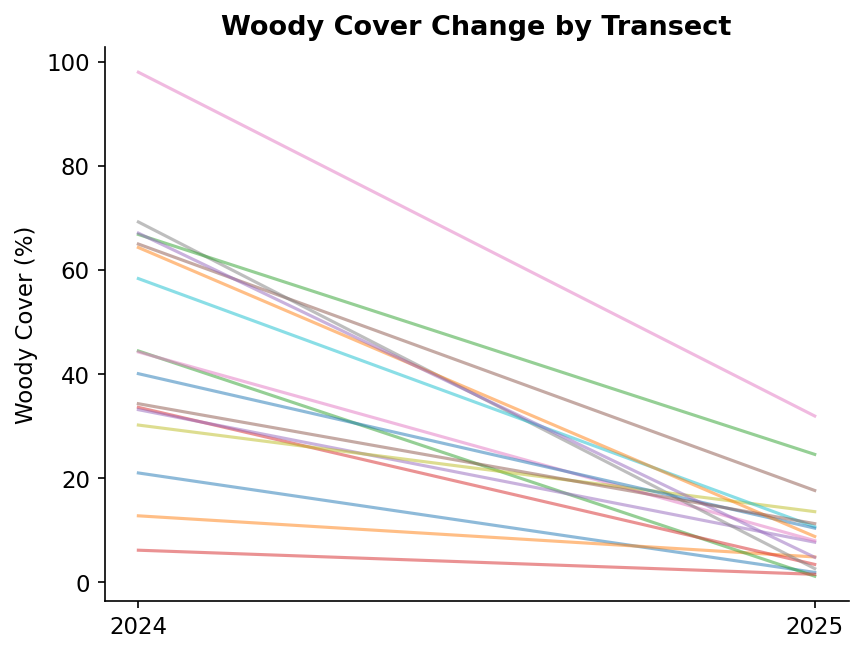

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for _, row in final_df.iterrows():
    plt.plot([0, 1],
             [row['woody_2024'], row['woody_2025']],
             alpha=0.5)

plt.xticks([0, 1], ['2024', '2025'])
plt.ylabel('Woody Cover (%)')
plt.title('Woody Cover Change by Transect')

plt.show()

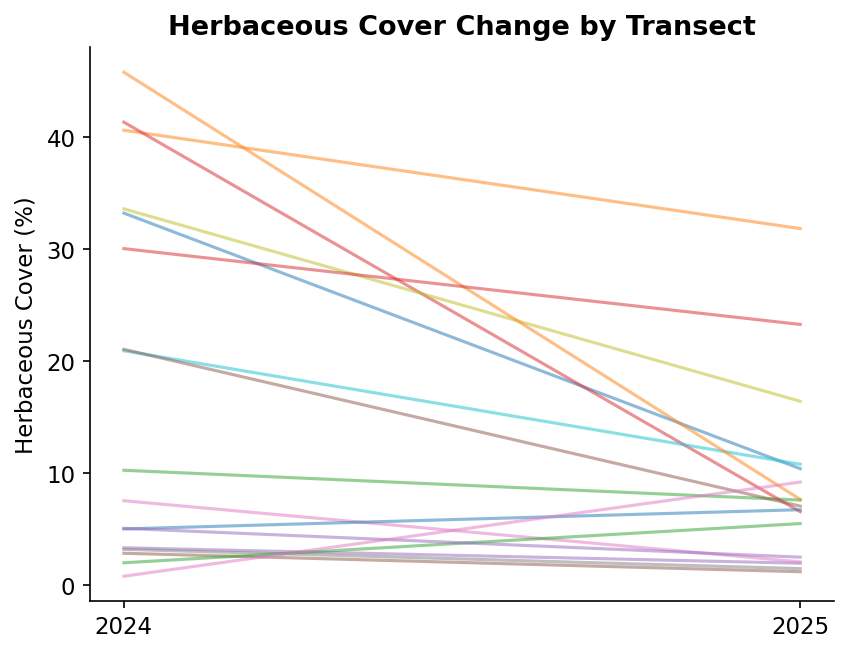

In [ ]:
plt.figure()

for _, row in final_df.iterrows():
    plt.plot([0, 1],
             [row['herb_2024'], row['herb_2025']],
             alpha=0.5)

plt.xticks([0, 1], ['2024', '2025'])
plt.ylabel('Herbaceous Cover (%)')
plt.title('Herbaceous Cover Change by Transect')

plt.show()

Fuel vs Woody Loss

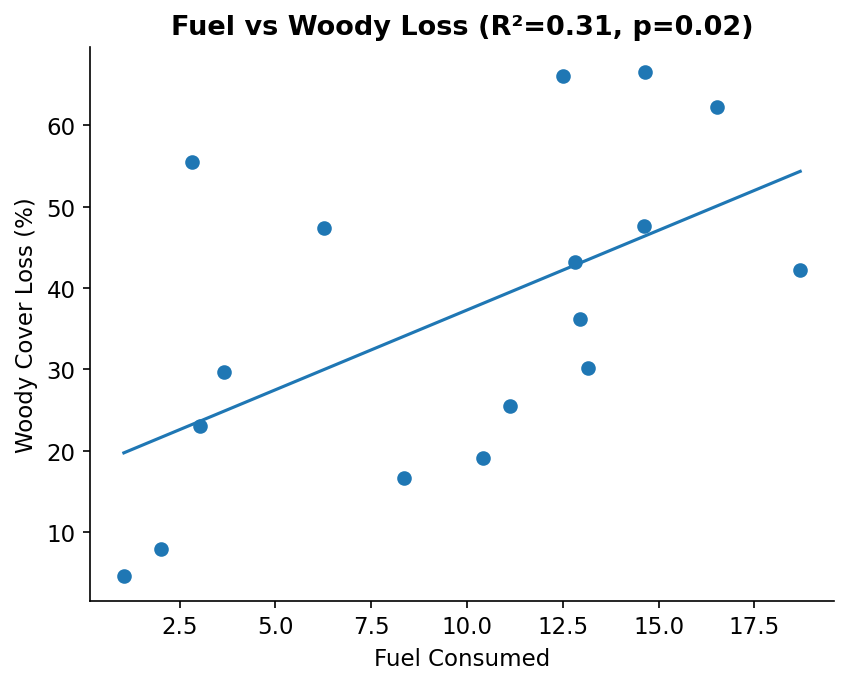

In [ ]:
from scipy.stats import linregress
import numpy as np

fuel = -final_df['delta_fuel']
woody_loss = -final_df['delta_woody']

slope, intercept, r, p, _ = linregress(fuel, woody_loss)

plt.figure()

plt.scatter(fuel, woody_loss)

x = np.linspace(fuel.min(), fuel.max(), 100)
plt.plot(x, slope*x + intercept)

plt.xlabel('Fuel Consumed')
plt.ylabel('Woody Cover Loss (%)')
plt.title(f'Fuel vs Woody Loss (R²={r**2:.2f}, p={p:.02f})')

plt.show()

Fuel vs Herb

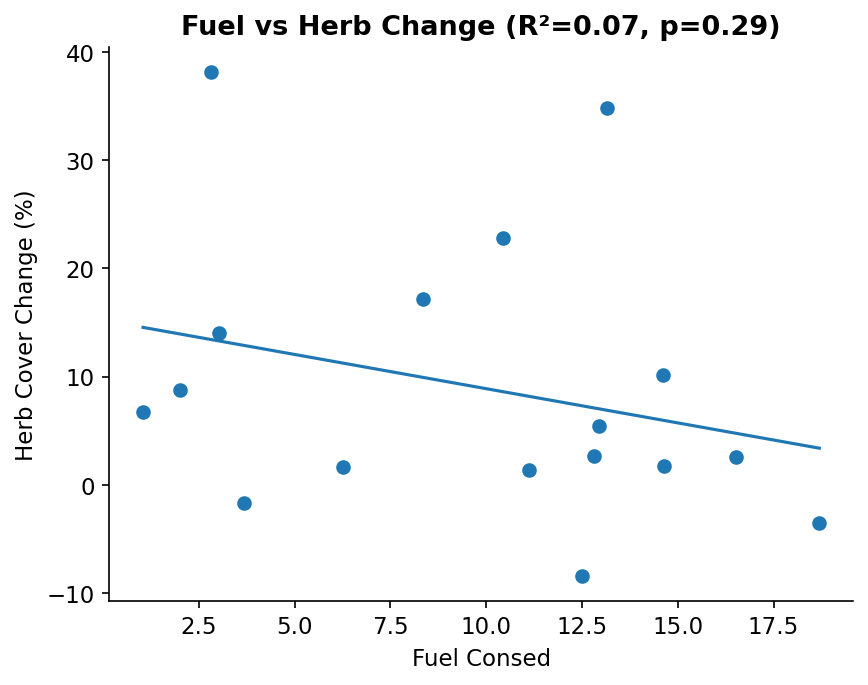

In [ ]:
herb_loss = -final_df['delta_herb']

slope, intercept, r, p, _ = linregress(fuel, herb_loss)

plt.figure()

plt.scatter(fuel, herb_loss)

x = np.linspace(fuel.min(), fuel.max(), 100)
plt.plot(x, slope*x + intercept)

plt.xlabel('Fuel Consed')
plt.ylabel('Herb Cover Change (%)')
plt.title(f'Fuel vs Herb Change (R²={r**2:.2f}, p={p:.02f})')

plt.show()

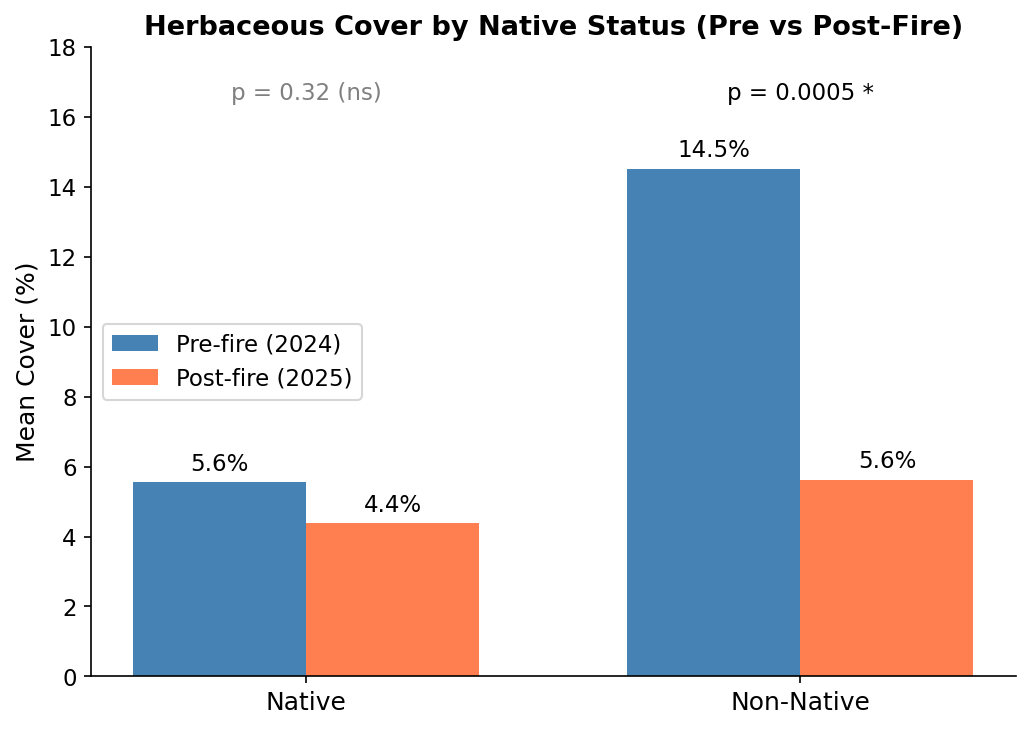

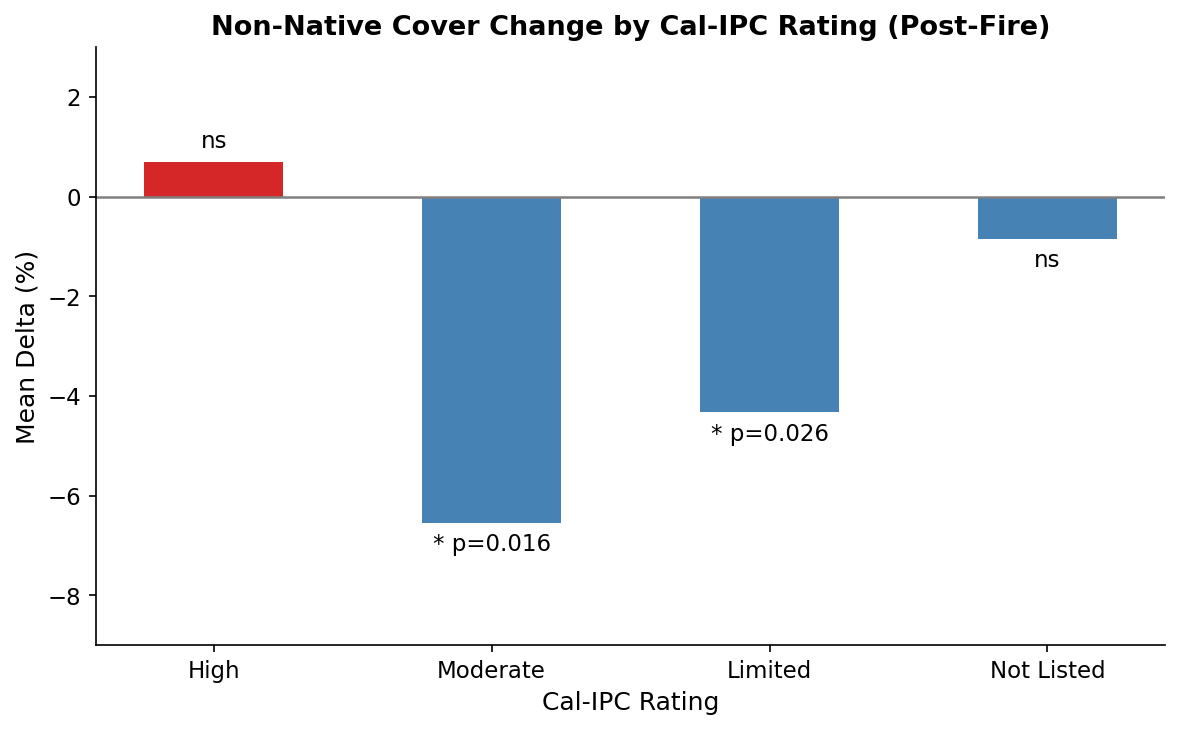

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# FIGURE 3A: Native vs Non-Native

categories = ['Native', 'Non-Native']
mean_2024  = [5.555, 14.525]
mean_2025  = [4.379, 5.624]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, mean_2024, width, label='Pre-fire (2024)', color='steelblue')
bars2 = ax.bar(x + width/2, mean_2025, width, label='Post-fire (2025)', color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Mean Cover (%)', fontsize=12)
ax.set_xlabel('')                    # ← fix here
ax.set_ylim(0, 18)
ax.set_title('Herbaceous Cover by Native Status (Pre vs Post-Fire)', fontsize=13)
ax.legend(fontsize=11)
ax.text(0, 16.5, 'p = 0.32 (ns)', ha='center', fontsize=11, color='gray')
ax.text(1, 16.5, 'p = 0.0005 *',  ha='center', fontsize=11, color='black')

plt.tight_layout()
plt.savefig('figure3a_native_nonnative.png', dpi=150)
plt.show()

# FIGURE 3B: Cal-IPC Delta
ratings = ['High', 'Moderate', 'Limited', 'Not Listed']
deltas  = [0.692, -6.547, -4.327, -0.849]
colors  = ['#d62728' if d > 0 else 'steelblue' for d in deltas]
sigs    = ['ns', '* p=0.016', '* p=0.026', 'ns']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ratings, deltas, color=colors, width=0.5)

ax.axhline(0, color='gray', linewidth=1.2)
ax.set_ylabel('Mean Delta (%)', fontsize=12)
ax.set_xlabel('Cal-IPC Rating', fontsize=12)
ax.set_ylim(-9, 3)
ax.set_title('Non-Native Cover Change by Cal-IPC Rating (Post-Fire)', fontsize=13)

for bar, sig, delta in zip(bars, sigs, deltas):
    offset = 0.2 if delta > 0 else -0.2
    va     = 'bottom' if delta > 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2,
            delta + offset, sig,
            ha='center', va=va, fontsize=11)

plt.tight_layout()
plt.savefig('figure3b_calipc.png', dpi=150)
plt.show()

In [ ]:
print(final_df.columns.tolist())

['transect_id', 'woody_2024', 'woody_2025', 'delta_woody', 'herb_2024', 'herb_2025', 'delta_herb', 'fuel_2024', 'fuel_2025', 'delta_fuel']


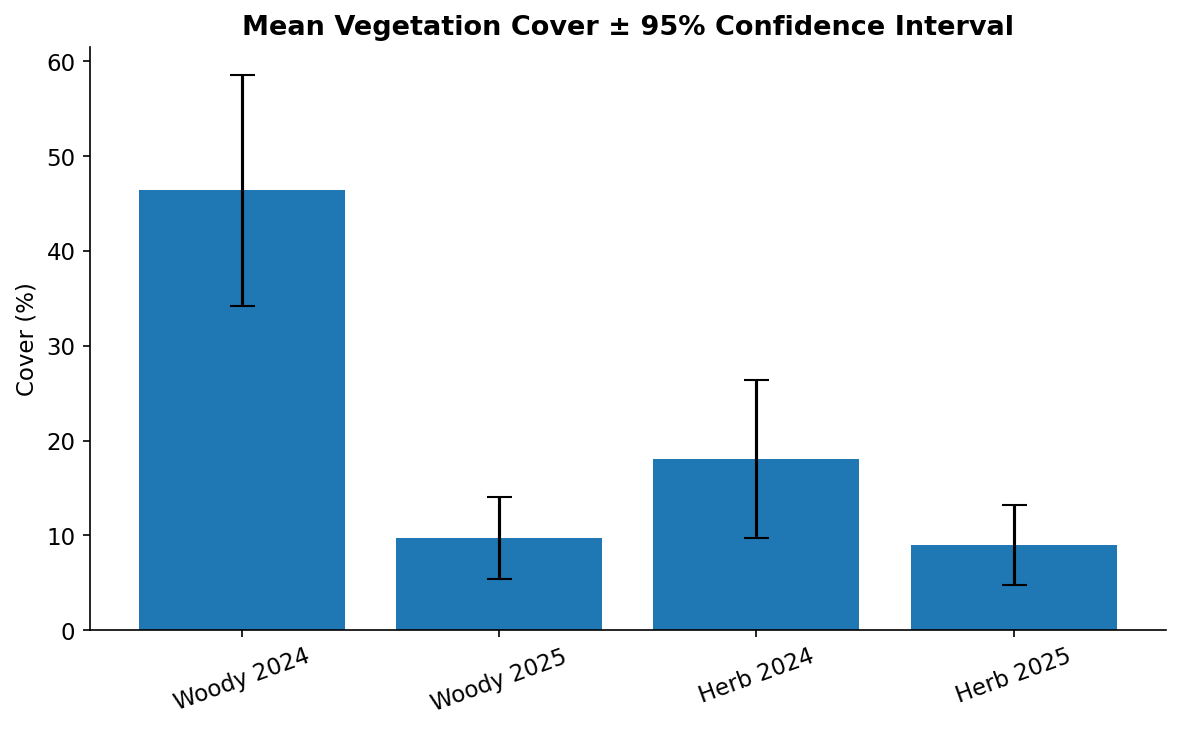

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

groups = {
    'Woody 2024': final_df['woody_2024'],
    'Woody 2025': final_df['woody_2025'],
    'Herb 2024' : final_df['herb_2024'],
    'Herb 2025' : final_df['herb_2025']
}

means = []
cis = []

for name, vals in groups.items():
    vals = vals.dropna()

    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ci = t.ppf(0.975, len(vals)-1) * sem

    means.append(mean)
    cis.append(ci)

plt.figure(figsize=(8,5))

plt.bar(
    range(len(means)),
    means,
    yerr=cis,
    capsize=6
)

plt.xticks(
    range(len(means)),
    groups.keys(),
    rotation=20
)

plt.ylabel('Cover (%)')
plt.title('Mean Vegetation Cover ± 95% Confidence Interval')

plt.tight_layout()
plt.show()

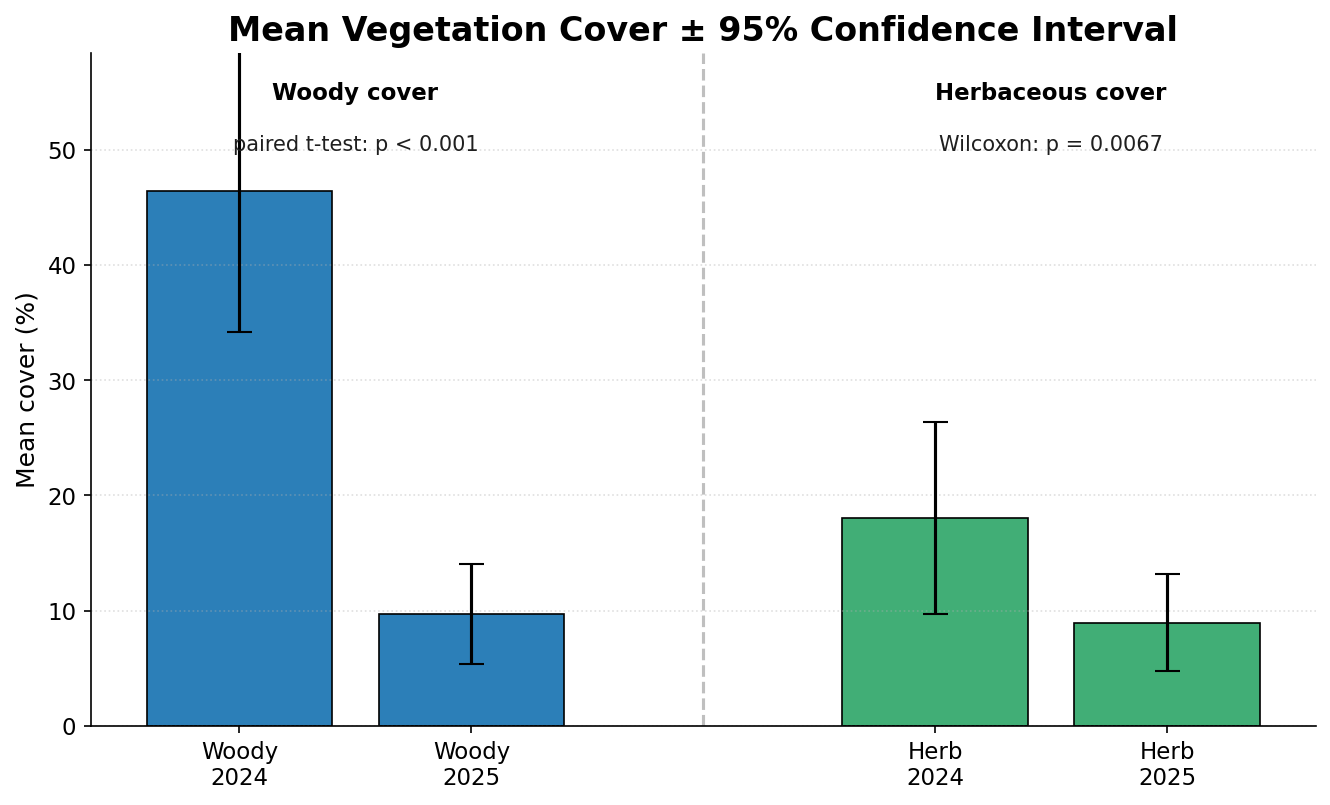

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

groups = {
    'Woody\n2024': final_df['woody_2024'],
    'Woody\n2025': final_df['woody_2025'],
    'Herb\n2024' : final_df['herb_2024'],
    'Herb\n2025' : final_df['herb_2025']
}

means = []
cis = []

for name, vals in groups.items():
    vals = vals.dropna()
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ci = t.ppf(0.975, len(vals)-1) * sem
    means.append(mean)
    cis.append(ci)

labels = list(groups.keys())
x = np.array([0, 1, 3, 4])
colors = ['#2C7FB8', '#2C7FB8', '#41AE76', '#41AE76']

plt.figure(figsize=(9, 5.5))

bars = plt.bar(
    x,
    means,
    yerr=cis,
    capsize=6,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

plt.xticks(x, labels, fontsize=11)
plt.ylabel('Mean cover (%)', fontsize=12)
plt.title('Mean Vegetation Cover ± 95% Confidence Interval', fontsize=16, weight='bold')

plt.axvline(2, color='gray', linestyle='--', alpha=0.5)
plt.text(0.5, max(means) + 8, 'Woody cover', ha='center', fontsize=11, weight='bold')
plt.text(3.5, max(means) + 8, 'Herbaceous cover', ha='center', fontsize=11, weight='bold')

plt.text(0.5, max(means) + 3.5, 'paired t-test: p < 0.001', ha='center', fontsize=10, color='#1f1f1f')
plt.text(3.5, max(means) + 3.5, 'Wilcoxon: p = 0.0067', ha='center', fontsize=10, color='#1f1f1f')

plt.ylim(0, max(means) + 12)
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

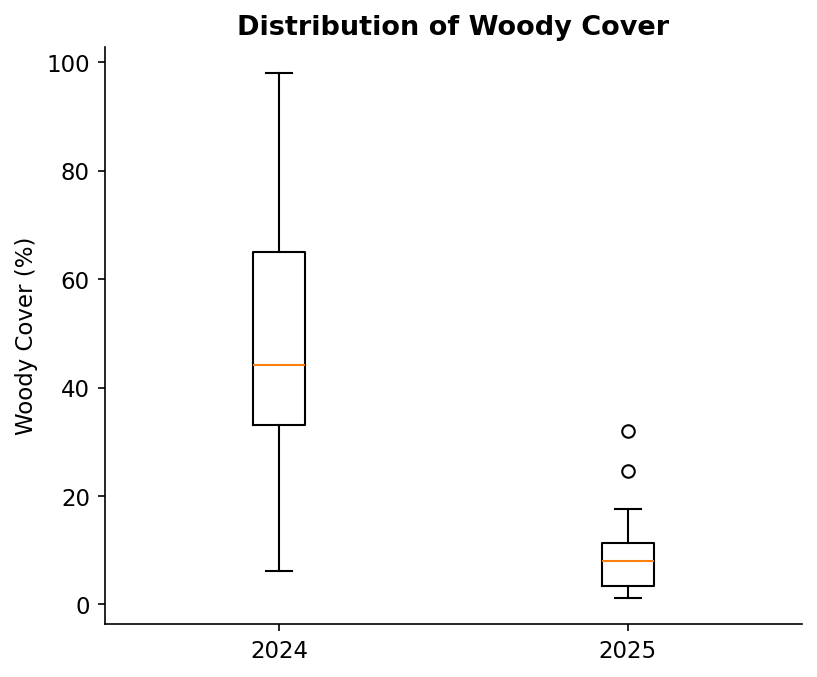

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot([
    final_df['woody_2024'],
    final_df['woody_2025']
])

plt.xticks([1,2], ['2024','2025'])
plt.ylabel('Woody Cover (%)')
plt.title('Distribution of Woody Cover')

plt.show()

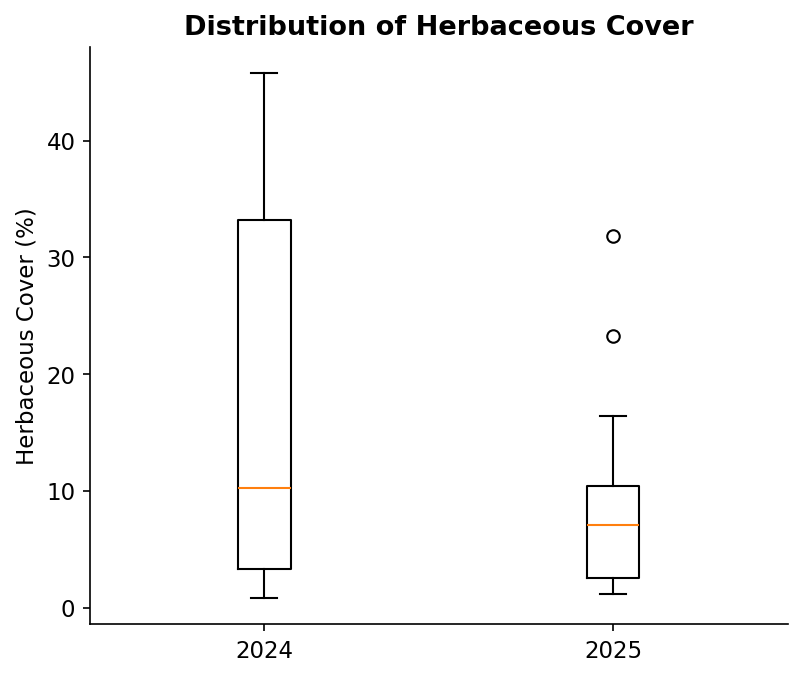

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot([
    final_df['herb_2024'],
    final_df['herb_2025']
])

plt.xticks([1,2], ['2024','2025'])
plt.ylabel('Herbaceous Cover (%)')
plt.title('Distribution of Herbaceous Cover')

plt.show()

/tmp/ipykernel_496/1351877611.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


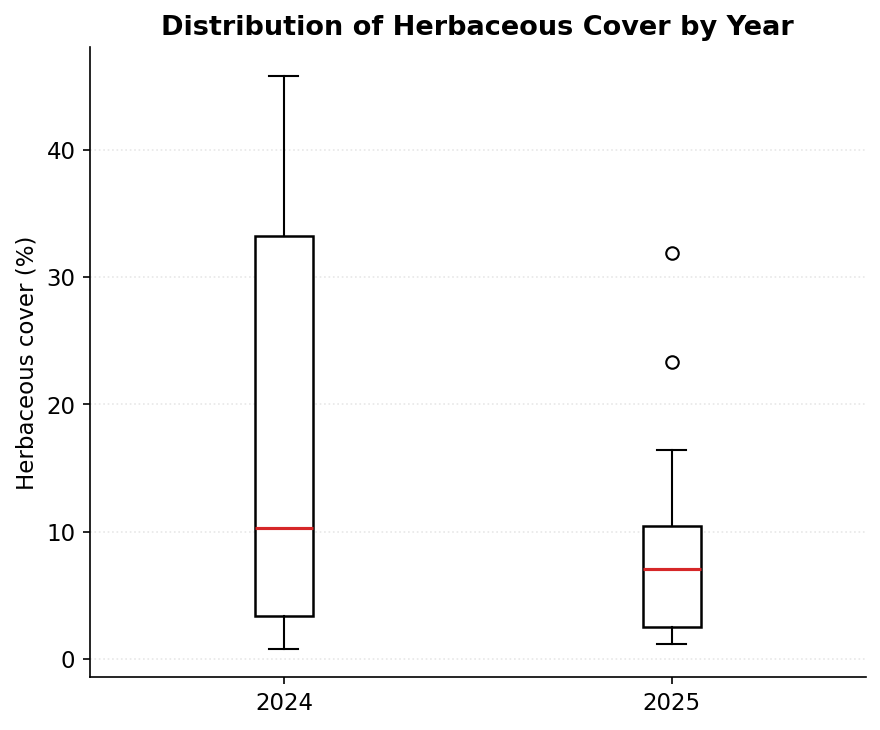

In [ ]:
plt.figure(figsize=(6,5))

bp = plt.boxplot(
    [final_df['herb_2024'], final_df['herb_2025']],
    labels=['2024','2025'],
    patch_artist=True
)

colors = ['#41AE76', '#41AE76']  # green for herb
for patch in bp['boxes']:
    patch.set(facecolor='white', edgecolor='black', linewidth=1.2)
for median in bp['medians']:
    median.set(color='#d62728', linewidth=1.5)

plt.ylabel('Herbaceous cover (%)')
plt.title('Distribution of Herbaceous Cover by Year', fontsize=13, weight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

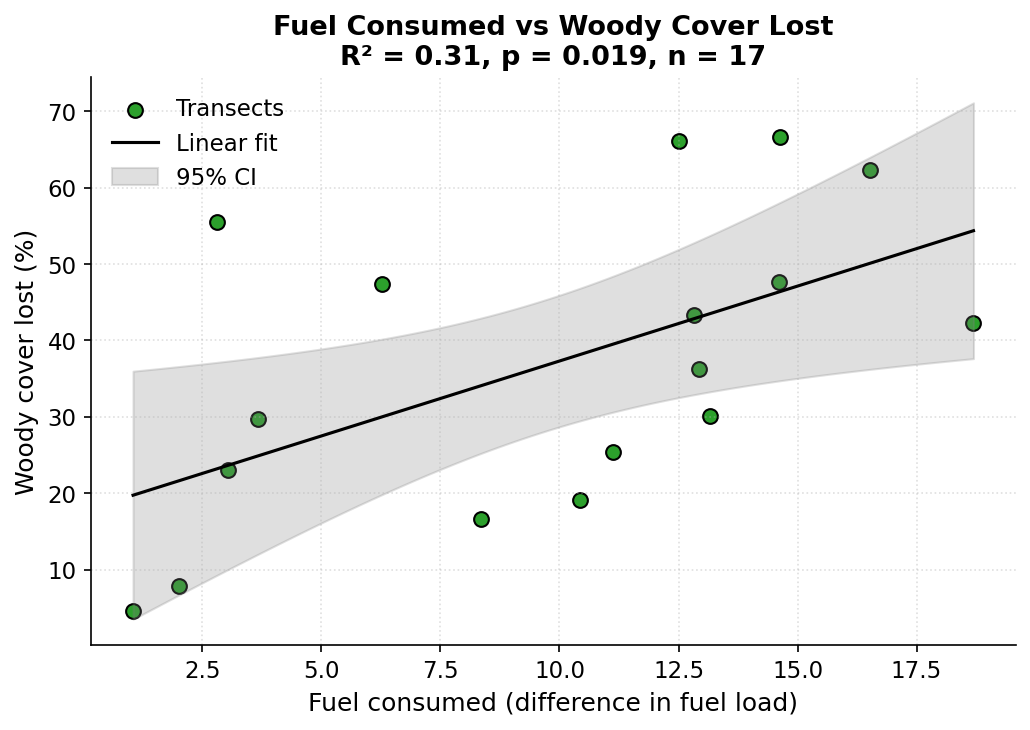

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Prepare variables
fuel_consumed = -final_df["delta_fuel"].values      # positive = fuel consumed
woody_lost = -final_df["delta_woody"].values       # positive = woody cover lost

# 2. Fit linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(fuel_consumed, woody_lost)

# Prediction grid
x_pred = np.linspace(fuel_consumed.min(), fuel_consumed.max(), 100)
y_pred = intercept + slope * x_pred

# 3. Compute 95% CI band for regression line
n = len(fuel_consumed)
t_crit = stats.t.ppf(0.975, df=n-2)

y_fit = intercept + slope * fuel_consumed
resid = woody_lost - y_fit
s_err = np.sqrt(np.sum(resid**2) / (n - 2))

x_bar = fuel_consumed.mean()
Sxx = np.sum((fuel_consumed - x_bar)**2)

ci = t_crit * s_err * np.sqrt(1/n + (x_pred - x_bar)**2 / Sxx)
lower = y_pred - ci
upper = y_pred + ci

# 4. Plot
plt.figure(figsize=(7,5))

plt.scatter(
    fuel_consumed,
    woody_lost,
    color="#2ca02c",
    edgecolor="black",
    s=50,
    label="Transects"
)

plt.plot(
    x_pred,
    y_pred,
    color="black",
    linewidth=1.5,
    label="Linear fit"
)

plt.fill_between(
    x_pred,
    lower,
    upper,
    color="grey",
    alpha=0.25,
    label="95% CI"
)

plt.xlabel("Fuel consumed (difference in fuel load)", fontsize=12)
plt.ylabel("Woody cover lost (%)", fontsize=12)

plt.title(
    f"Fuel Consumed vs Woody Cover Lost\n"
    f"R² = {r_value**2:.2f}, p = {p_value:.3f}, n = {n}",
    fontsize=13,
    weight="bold"
)

plt.grid(axis='both', linestyle=':', alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

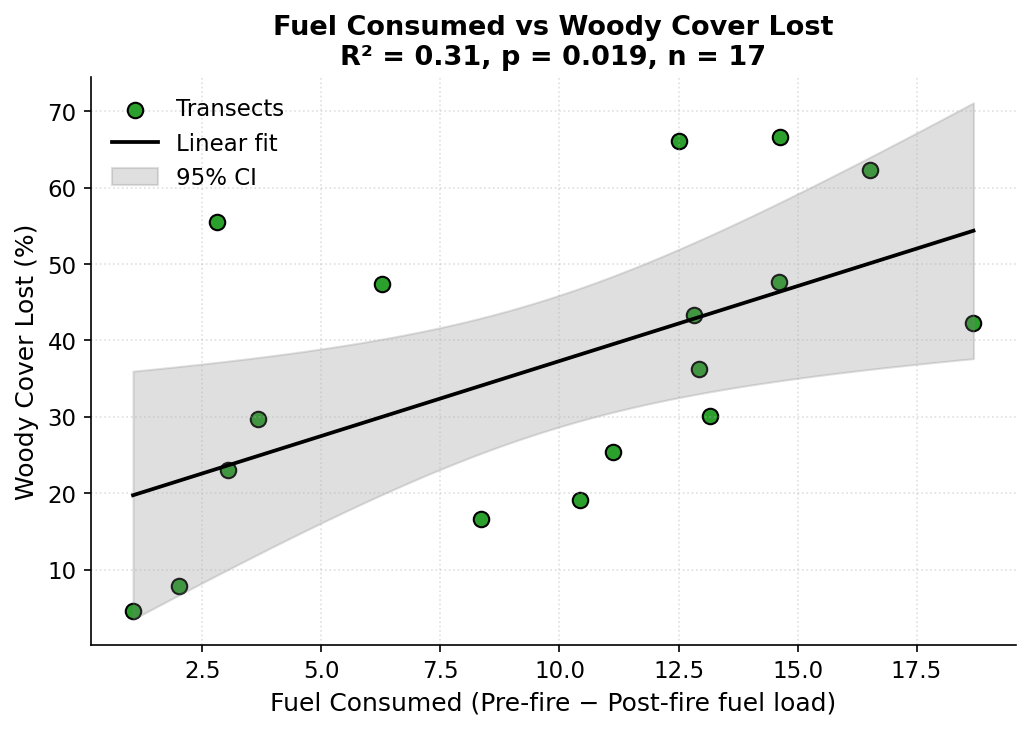

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Data
fuel_consumed = -final_df["delta_fuel"].values
woody_lost = -final_df["delta_woody"].values

# Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    fuel_consumed, woody_lost
)

x_pred = np.linspace(fuel_consumed.min(), fuel_consumed.max(), 100)
y_pred = intercept + slope * x_pred

# 95% CI for regression line
n = len(fuel_consumed)
t_crit = stats.t.ppf(0.975, df=n-2)

y_fit = intercept + slope * fuel_consumed
resid = woody_lost - y_fit
s_err = np.sqrt(np.sum(resid**2) / (n - 2))

x_bar = fuel_consumed.mean()
Sxx = np.sum((fuel_consumed - x_bar)**2)

ci = t_crit * s_err * np.sqrt(1/n + (x_pred - x_bar)**2 / Sxx)
lower = y_pred - ci
upper = y_pred + ci

# Plot
plt.figure(figsize=(7, 5))

plt.scatter(
    fuel_consumed,
    woody_lost,
    color="#2ca02c",
    edgecolor="black",
    s=55,
    label="Transects"
)

plt.plot(
    x_pred,
    y_pred,
    color="black",
    linewidth=1.8,
    label="Linear fit"
)

plt.fill_between(
    x_pred,
    lower,
    upper,
    color="grey",
    alpha=0.25,
    label="95% CI"
)

plt.xlabel("Fuel Consumed (Pre-fire − Post-fire fuel load)", fontsize=12)
plt.ylabel("Woody Cover Lost (%)", fontsize=12)

plt.title(
    f"Fuel Consumed vs Woody Cover Lost\n"
    f"R² = {r_value**2:.2f}, p = {p_value:.3f}, n = {n}",
    fontsize=13,
    weight="bold"
)

plt.grid(axis="both", linestyle=":", alpha=0.4)
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("fig_fuel_vs_woody_loss_ci.png", dpi=300, bbox_inches="tight")
plt.show()